In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Libraries loaded ')

Libraries loaded 


In [11]:
train_id=pd.read_csv('D:\\Fraud-Detection\\Project-One\\notebooks\\data\\train_identity.csv')
test_id=pd.read_csv('D:\\Fraud-Detection\\Project-One\\notebooks\\data\\test_identity.csv')

In [12]:
train_id.shape, test_id.shape

((144233, 41), (141907, 41))

In [13]:
print(test_id.columns)
print("----"*20)
print(train_id.columns)

Index(['TransactionID', 'id-01', 'id-02', 'id-03', 'id-04', 'id-05', 'id-06',
       'id-07', 'id-08', 'id-09', 'id-10', 'id-11', 'id-12', 'id-13', 'id-14',
       'id-15', 'id-16', 'id-17', 'id-18', 'id-19', 'id-20', 'id-21', 'id-22',
       'id-23', 'id-24', 'id-25', 'id-26', 'id-27', 'id-28', 'id-29', 'id-30',
       'id-31', 'id-32', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38',
       'DeviceType', 'DeviceInfo'],
      dtype='object')
--------------------------------------------------------------------------------
Index(['TransactionID', 'id_01', 'id_02', 'id_03', 'id_04', 'id_05', 'id_06',
       'id_07', 'id_08', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14',
       'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22',
       'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30',
       'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38',
       'DeviceType', 'DeviceInfo'],
      dtype='object')


In [14]:
test_id.columns = test_id.columns.str.replace('-', '_')

In [15]:
# Tag source before combining
train_id['source'] = 'train'
test_id['source']  = 'test'
test_id['isFraud'] = np.nan   # test has no label

In [16]:
train_id.head(2)
test_id.head(2)

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,source,isFraud
0,3663586,-45.0000,280290.0000,NaN,NaN,0.0000,0.0000,NaN,NaN,NaN,NaN,100.0000,NotFound,27.0000,NaN,New,NotFound,225.0000,15.0000,427.0000,563.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 67.0 for android,NaN,NaN,NaN,F,F,T,F,mobile,MYA-L13 Build/HUAWEIMYA-L13,test,NaN
1,3663588,0.0000,3579.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,0.0000,100.0000,Found,NaN,-300.0000,Found,Found,166.0000,NaN,542.0000,368.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Android 6.0.1,chrome 67.0 for android,24.0000,1280x720,match_status:2,T,F,T,T,mobile,LGLS676 Build/MXB48T,test,NaN


In [18]:

df_id = pd.concat([train_id, test_id], axis=0, ignore_index=True)
df_id.to_parquet("data/identity.parquet", index=False)
print(f'Train identity : {train_id.shape}')
print(f'Test identity  : {test_id.shape}')
print(f'Combined       : {df_id.shape}')

Train identity : (144233, 42)
Test identity  : (141907, 43)
Combined       : (286140, 43)


In [19]:
dtype_summary = df_id.dtypes.value_counts().reset_index()
dtype_summary.columns = ['dtype', 'count']
print('--- Data Types Summary ---')
print(dtype_summary.to_string(index=False))

num_cols_id = df_id.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_id = df_id.select_dtypes(include=['object']).columns.tolist()
cat_cols_id = [c for c in cat_cols_id if c != 'source']

print(f'\nNumeric columns    : {len(num_cols_id)}')
print(f'Categorical columns: {len(cat_cols_id)}')
print(f'Categorical cols   : {cat_cols_id}')

--- Data Types Summary ---
  dtype  count
float64     24
 object     18
  int64      1

Numeric columns    : 25
Categorical columns: 17
Categorical cols   : ['id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [21]:
# ── 3. Missing Values ────────────────────────────────────────────
missing_id = pd.DataFrame({
    'missing_count': df_id.isnull().sum(),
    'missing_pct'  : (df_id.isnull().sum() / len(df_id)) * 100
}).sort_values('missing_pct', ascending=False)

missing_id = missing_id[missing_id['missing_count'] > 0]
print(f'Columns with missing values: {len(missing_id)} / {df_id.shape[1]}')
print(f'\nAll columns by missing %:')
print(missing_id.to_string())

Columns with missing values: 39 / 43

All columns by missing %:
            missing_count  missing_pct
isFraud            286140     100.0000
id_24              276653      96.6845
id_25              275969      96.4454
id_26              275930      96.4318
id_07              275926      96.4304
id_08              275926      96.4304
id_21              275922      96.4290
id_23              275909      96.4245
id_22              275909      96.4245
id_27              275909      96.4245
id_18              190152      66.4542
id_04              153335      53.5874
id_03              153335      53.5874
id_33              142180      49.6890
id_30              137916      48.1988
id_32              137883      48.1873
id_10              136876      47.8353
id_09              136876      47.8353
id_34              136160      47.5851
id_14              134739      47.0885
DeviceInfo          52417      18.3187
id_16               31053      10.8524
id_13               28534       9.9720


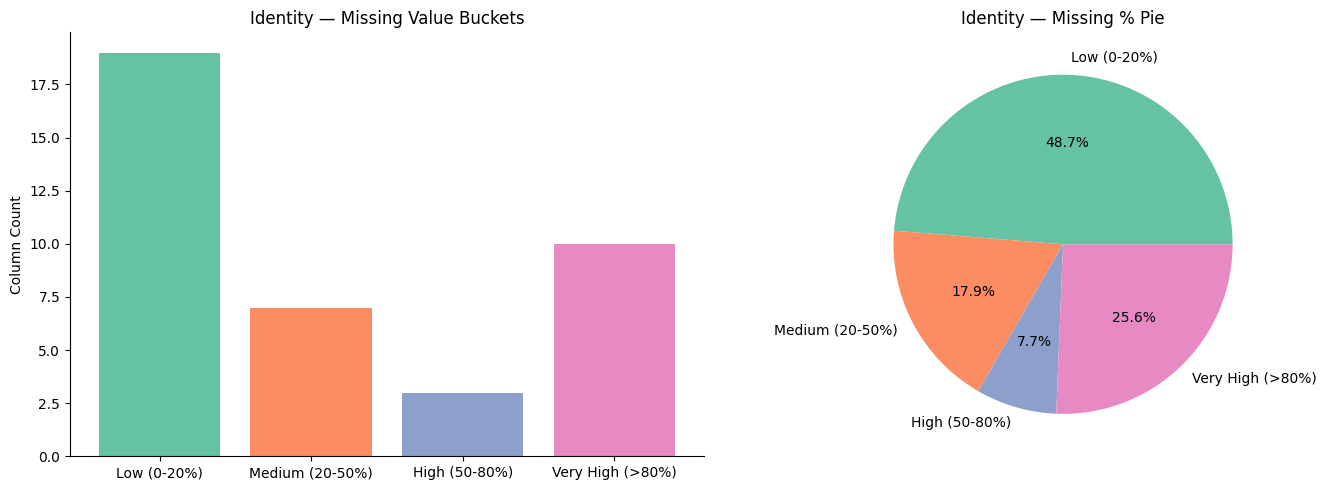


Decision: DROP 13 columns with >50% missing


In [22]:


# Bucket plot
buckets = {
    'Low (0-20%)'     : ((missing_id['missing_pct'] > 0)  & (missing_id['missing_pct'] <= 20)).sum(),
    'Medium (20-50%)' : ((missing_id['missing_pct'] > 20) & (missing_id['missing_pct'] <= 50)).sum(),
    'High (50-80%)'   : ((missing_id['missing_pct'] > 50) & (missing_id['missing_pct'] <= 80)).sum(),
    'Very High (>80%)': (missing_id['missing_pct'] > 80).sum(),
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(buckets.keys(), buckets.values(), color=sns.color_palette('Set2'))
axes[0].set_title('Identity — Missing Value Buckets')
axes[0].set_ylabel('Column Count')
axes[1].pie([v for v in buckets.values() if v > 0],
            labels=[k for k, v in buckets.items() if v > 0],
            autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_title('Identity — Missing % Pie')
plt.tight_layout()
plt.show()
print(f'\nDecision: DROP {(missing_id["missing_pct"] > 50).sum()} columns with >50% missing')

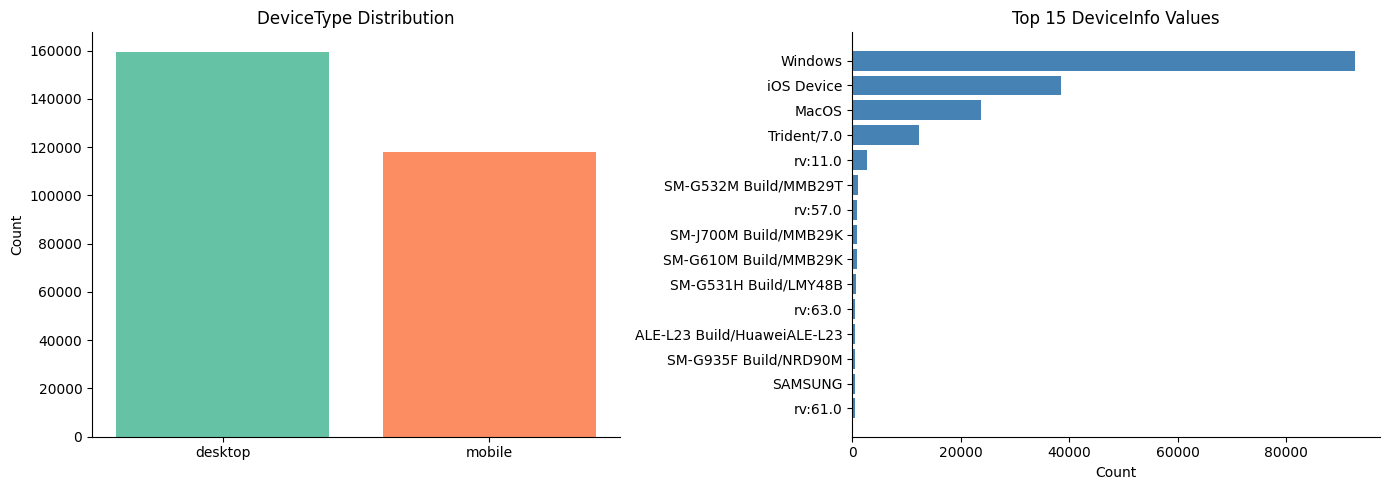


DeviceType value counts:
DeviceType
desktop    159568
mobile     118173
Name: count, dtype: int64


In [24]:
# ── 4. Device Type & Device Info ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# DeviceType
dt = df_id['DeviceType'].value_counts()
axes[0].bar(dt.index, dt.values, color=sns.color_palette('Set2'))
axes[0].set_title('DeviceType Distribution')
axes[0].set_ylabel('Count')

# DeviceInfo top 15
di = df_id['DeviceInfo'].value_counts().head(15)
axes[1].barh(di.index[::-1], di.values[::-1], color='steelblue')
axes[1].set_title('Top 15 DeviceInfo Values')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print('\nDeviceType value counts:')
print(df_id['DeviceType'].value_counts())

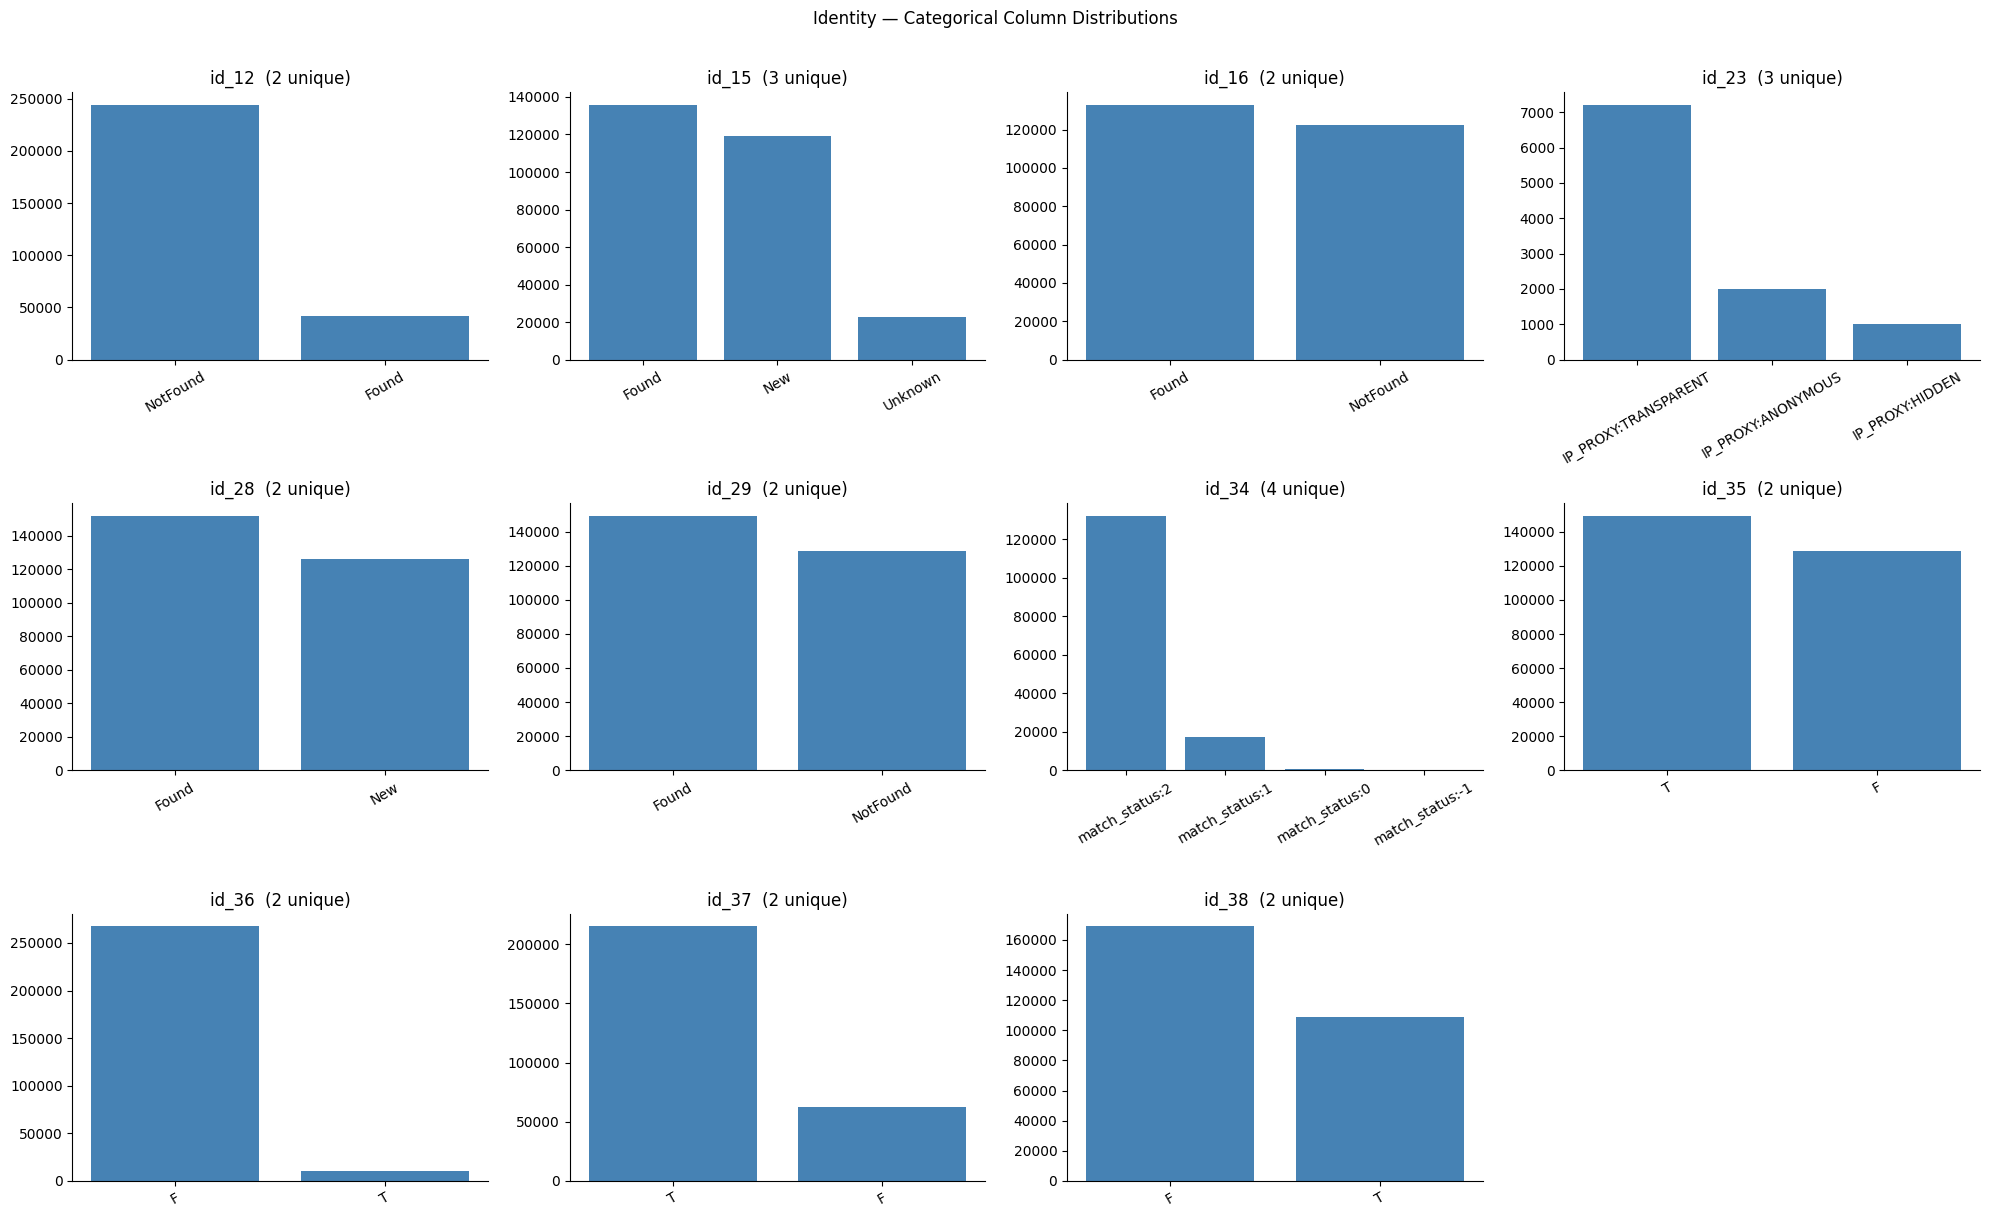

In [28]:
# ── 5. Categorical Columns Distribution ──────────────────────────
key_cats = ['id_12', 'id_15', 'id_16', 'id_23', 'id_28', 'id_29',
            'id_34', 'id_35', 'id_36', 'id_37', 'id_38']
## not include source, device type and device info.
key_cats = [c for c in key_cats if c in df_id.columns]

rows = (len(key_cats) + 3) // 4
fig, axes = plt.subplots(rows, 4, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(key_cats):
    vc = df_id[col].value_counts().head(8)
    axes[i].bar(vc.index.astype(str), vc.values, color='steelblue')
    axes[i].set_title(f'{col}  ({df_id[col].nunique()} unique)')
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Identity — Categorical Column Distributions', y=1.01)
plt.tight_layout()
plt.show()

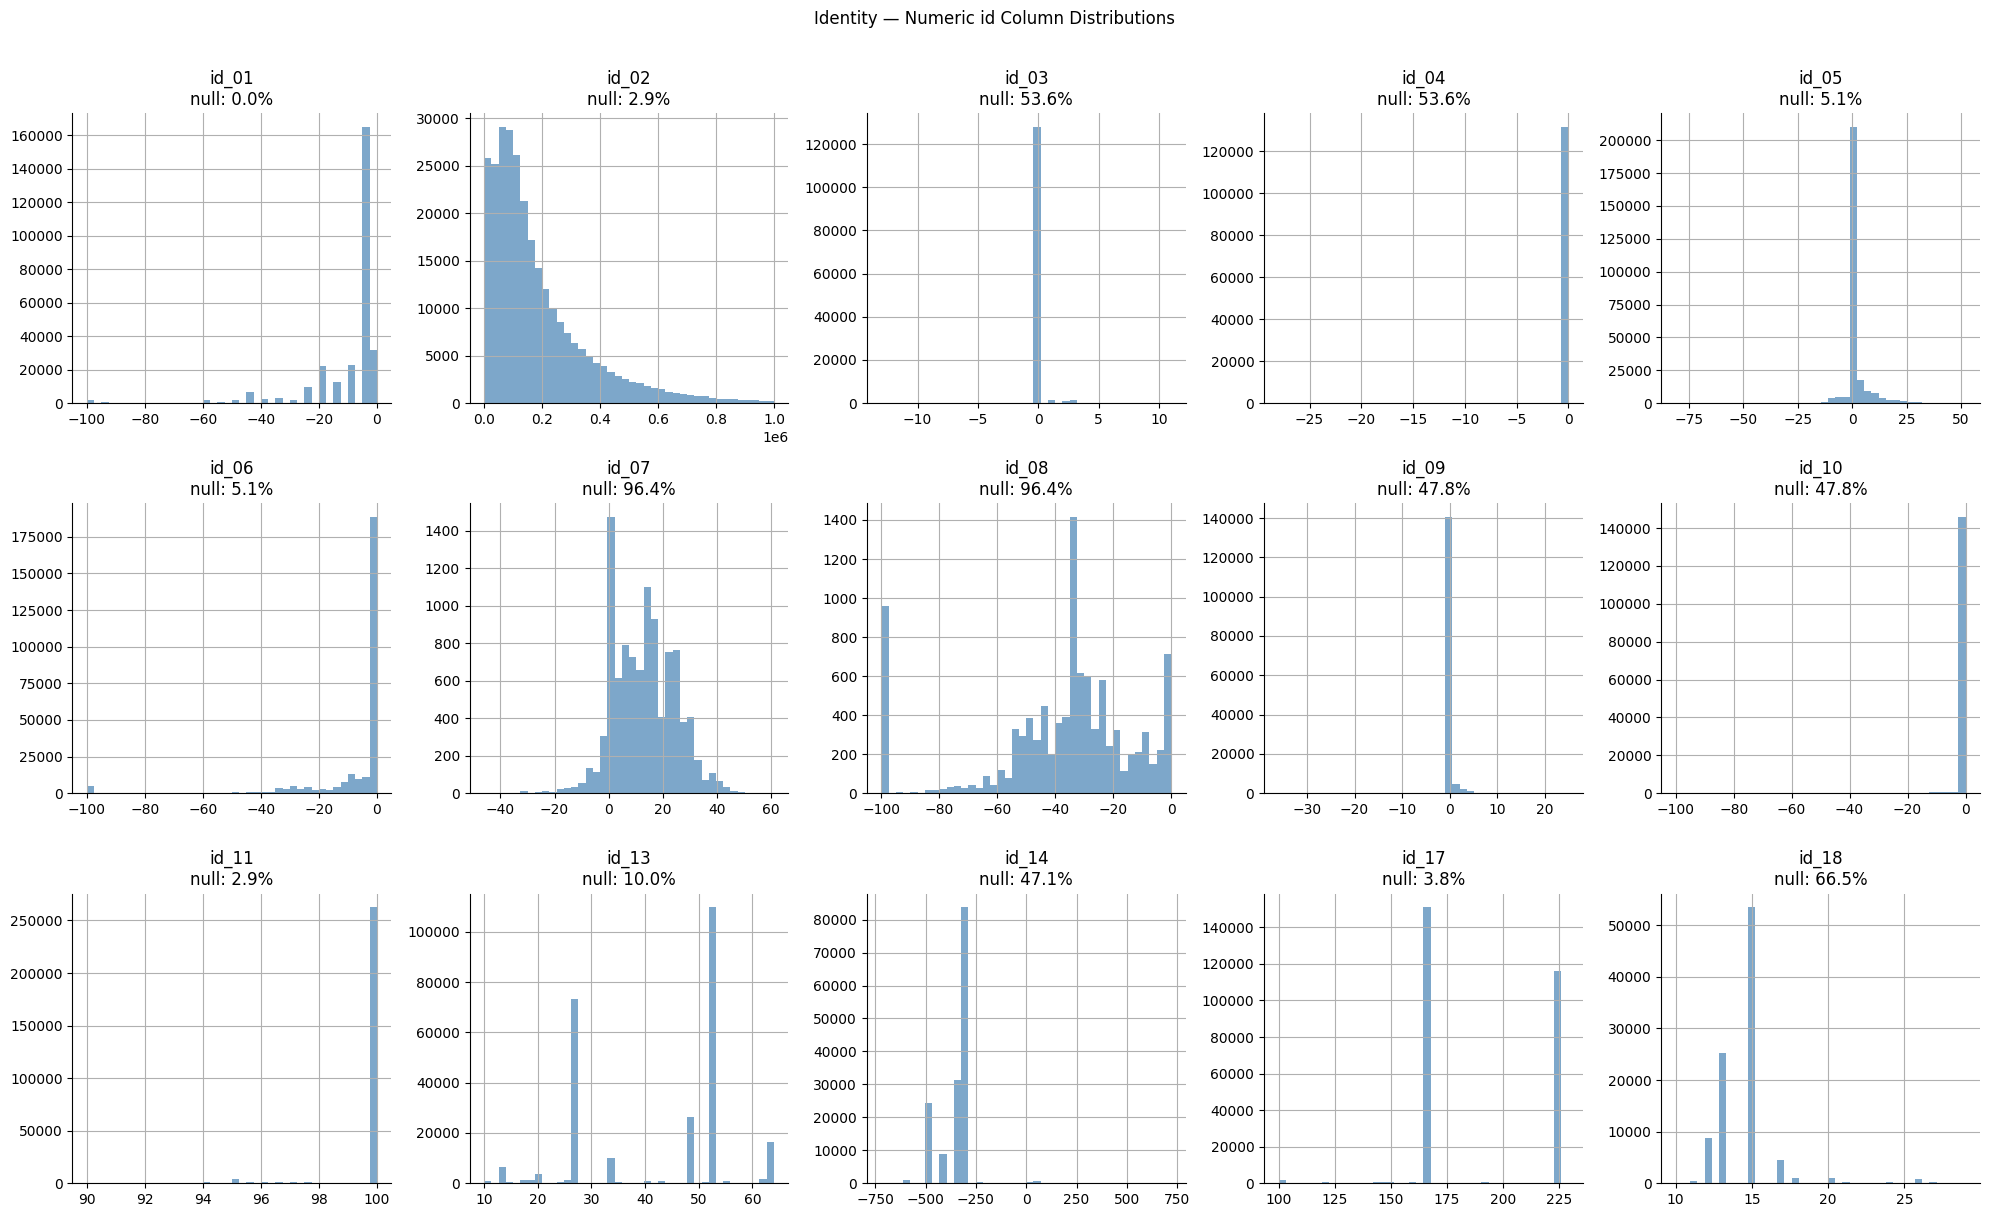

In [29]:
# ── 6. Numeric id columns distribution ───────────────────────────
num_id_cols = [c for c in num_cols_id
               if c.startswith('id_') and c in df_id.columns]

plot_cols = num_id_cols[:15]
rows = (len(plot_cols) + 4) // 5
fig, axes = plt.subplots(rows, 5, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    df_id[col].hist(bins=40, ax=axes[i], color='steelblue', alpha=0.7)
    axes[i].set_title(f'{col}\nnull: {df_id[col].isnull().mean()*100:.1f}%')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Identity — Numeric id Column Distributions', y=1.01)
plt.tight_layout()
plt.show()

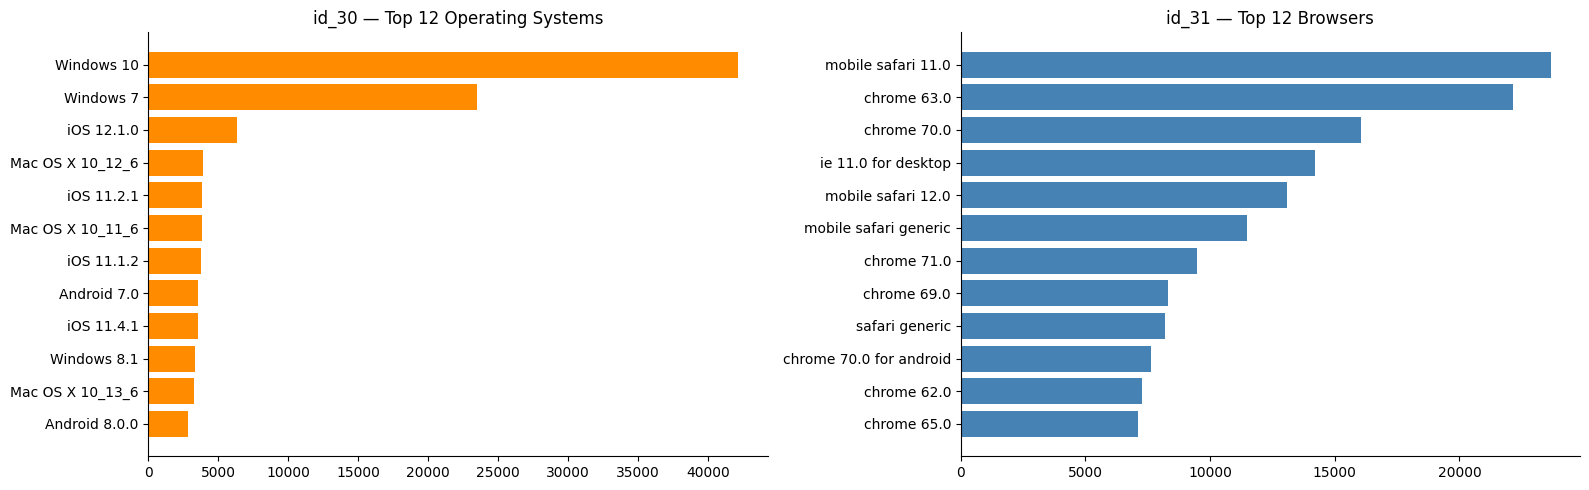

In [30]:
# ── 7. id_30 (OS) and id_31 (Browser) ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

os_counts = df_id['id_30'].value_counts().head(12)
axes[0].barh(os_counts.index[::-1], os_counts.values[::-1], color='darkorange')
axes[0].set_title('id_30 — Top 12 Operating Systems')

br_counts = df_id['id_31'].value_counts().head(12)
axes[1].barh(br_counts.index[::-1], br_counts.values[::-1], color='steelblue')
axes[1].set_title('id_31 — Top 12 Browsers')

plt.tight_layout()
plt.show()

In [31]:
# ── 8. Keep / Drop Decision ──────────────────────────────────────
missing_pct_id     = (df_id.isnull().sum() / len(df_id)) * 100
drop_high_id       = missing_pct_id[missing_pct_id > 50].index.tolist()
drop_zero_var_id   = [c for c in df_id.columns if df_id[c].nunique() <= 1]

always_keep_id = [
    'TransactionID', 'DeviceType', 'DeviceInfo',
    'id_12', 'id_15', 'id_16', 'id_28', 'id_29',
    'id_30', 'id_31', 'id_35', 'id_36', 'id_37', 'id_38'
]

all_drops_id = set(drop_high_id + drop_zero_var_id) - set(always_keep_id)
keep_cols_id = [c for c in df_id.columns
                if c not in all_drops_id and c != 'source']

print('=== Identity Feature Keep/Drop ===')
print(f'Total columns         : {df_id.shape[1]}')
print(f'Drop >50% missing     : {len(drop_high_id)}')
print(f'Drop zero variance    : {len(drop_zero_var_id)}')
print(f'Total columns to DROP : {len(all_drops_id)}')
print(f'Columns to KEEP       : {len(keep_cols_id)}')
print(f'\nKept columns: {keep_cols_id}')

=== Identity Feature Keep/Drop ===
Total columns         : 43
Drop >50% missing     : 13
Drop zero variance    : 1
Total columns to DROP : 13
Columns to KEEP       : 29

Kept columns: ['TransactionID', 'id_01', 'id_02', 'id_05', 'id_06', 'id_09', 'id_10', 'id_11', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_19', 'id_20', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


In [34]:
# ── 9. Save Graphs + Summary ─────────────────────────────────────
GRAPH_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'EDA_output_Graphs_identity')
os.makedirs(GRAPH_DIR, exist_ok=True)


summary_id = f"""
================================================================================
IEEE-CIS FRAUD DETECTION — IDENTITY DATASET EDA SUMMARY
================================================================================

DATASET OVERVIEW
  Train identity rows : {train_id.shape[0]:,}
  Test identity rows  : {test_id.shape[0]:,}
  Combined rows       : {df_id.shape[0]:,}
  Columns             : {df_id.shape[1]}
  Coverage            : ~13% of all transactions have identity info

NOTE ON COLUMN NAMES
  Train uses underscores (id_01), test uses dashes (id-01).
  Standardized to underscores before combining.

MISSING VALUES
  Columns >50% null   : {len(drop_high_id)} → DROPPED
  High null group     : id_07/id_08, id_21–id_27 (96–97% null, proxy/VPN signals)
  id_23               : IP proxy type — IP_PROXY:TRANSPARENT / ANONYMOUS / HIDDEN
  Always kept despite nulls: DeviceType, DeviceInfo, id_30, id_31, id_12 etc.

DEVICE ANALYSIS
  DeviceType  : desktop (~59%) / mobile (~41%)  | 2.4% null
  DeviceInfo  : 1786 unique values — Windows/iOS/MacOS dominate top values | 17.7% null

CATEGORICAL COLUMNS
  id_12 : Found / NotFound           — 0% null
  id_15 : Found / New / Unknown      — 2.3% null
  id_16 : Found / NotFound           — 10.3% null
  id_23 : IP proxy type              — 96.4% null (very sparse)
  id_28 : Found / New                — 2.3% null
  id_29 : Found / NotFound           — 2.3% null
  id_34 : match_status 0/1/2/-1      — 46.1% null
  id_35–id_38 : T/F boolean flags    — 2.3% null

OS & BROWSER (id_30 / id_31)
  id_30 : 75 unique OS values  — Windows 10 dominant | 46% null
  id_31 : 130 unique browsers  — Chrome 63 dominant  | 2.7% null
  These are strong device fingerprint features for fraud detection.

MERGE STRATEGY
  Join key    : TransactionID
  Join type   : LEFT JOIN (transaction is master table)
  Result      : ~1.1M rows, identity cols NaN where no match (~87% of rows)
  NaN handling: XGBoost handles NaN natively — no forced imputation needed

FEATURE KEEP/DROP
  Columns to KEEP : {len(keep_cols_id)}
  Dropped         : id_07, id_08, id_21–id_27 (>50% null, not in always_keep)

================================================================================
END OF IDENTITY EDA SUMMARY
================================================================================
"""
SUMMARY_PATH = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'data', 'EDA_identity_summary.txt')
with open(SUMMARY_PATH, 'w', encoding='utf-8') as f:
    f.write(summary_id)

print('✓ Identity EDA summary saved to notebooks/data/EDA_identity_summary.txt')
print('✓ All graphs saved to notebooks/EDA_output_Graphs_identity/')
print('\nNEXT STEP → Merge transaction + identity → Feature Engineering')

✓ Identity EDA summary saved to notebooks/data/EDA_identity_summary.txt
✓ All graphs saved to notebooks/EDA_output_Graphs_identity/

NEXT STEP → Merge transaction + identity → Feature Engineering


In [35]:
# At the top of your save cell — replace GRAPH_DIR line with this
GRAPH_DIR = os.path.join(os.getcwd(), 'identity_EDA_output_Graphs')
os.makedirs(GRAPH_DIR, exist_ok=True)

def save_fig(name):
    plt.savefig(os.path.join(GRAPH_DIR, f'{name}.png'),
                dpi=150, bbox_inches='tight')
    plt.close()

print(f'Graph folder: {GRAPH_DIR}')  # confirm exact path before running

Graph folder: d:\Fraud-Detection\Project-One\notebooks\identity_EDA_output_Graphs
